# LSTM（Long Short-Term Memory）を理解する

RNN の限界（勾配消失、自己回帰生成での波形崩れ）を体験した上で、
LSTM がそれを **どう解決するか** を学びます。

| Step | 内容 | 目的 |
|------|------|------|
| 1 | LSTM セルの仕組みを理解 | 3つのゲートとセル状態の役割 |
| 2 | NumPy で LSTM をスクラッチ実装 | ゲート計算を手で書いて体感 |
| 3 | PyTorch `nn.LSTM` で正弦波予測 | RNN と同じタスクで実装 |
| 4 | RNN vs LSTM を比較 | 自己回帰生成の品質差を確認 |
| 5 | ゲートの中身を可視化 | LSTM が何を学んだか確認 |

---
## Step 1: LSTM セルの仕組みを理解する

### RNN の問題（おさらい）

RNN は1つの隠れ状態 $h_t$ だけで全ての記憶をやりくりしていました。

```
RNN:  h_t = tanh(W_ih @ x_t + W_hh @ h_{t-1})
      ^^^   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
      記憶は  毎回 tanh で -1〜1 に押し潰される
      1つだけ  → 長期記憶が薄れていく
```

### LSTM の解決策: 2つの記憶 + 3つのゲート

LSTM は **セル状態（長期記憶）** を別に持ち、**ゲート** で情報の流れを制御します。

```
                    忘却ゲート    入力ゲート
                       ↓            ↓
c_{t-1} ──→ [× forget] ──→ [+ new info] ──→ c_t    ← セル状態（長期記憶）
                                                ↓
                                          [× output gate]
                                                ↓
                                          tanh(c_t) → h_t  ← 隠れ状態（短期記憶）
```

### 3つのゲートの役割

| ゲート | 数式 | 出力範囲 | 役割 |
|--------|------|----------|------|
| **忘却ゲート** $f_t$ | $\sigma(W_f [h_{t-1}, x_t] + b_f)$ | 0〜1 | 前のセル状態をどれだけ **残すか** |
| **入力ゲート** $i_t$ | $\sigma(W_i [h_{t-1}, x_t] + b_i)$ | 0〜1 | 新しい情報をどれだけ **書き込むか** |
| **出力ゲート** $o_t$ | $\sigma(W_o [h_{t-1}, x_t] + b_o)$ | 0〜1 | セル状態をどれだけ **外に出すか** |

$\sigma$ は sigmoid 関数（0〜1 に収める）。ゲートが **バルブ** のように情報の流量を調節します。

### LSTM の全計算（4ステップ）

```
① 忘却:   f_t = σ(W_f [h_{t-1}, x_t] + b_f)         何を忘れるか
② 入力:   i_t = σ(W_i [h_{t-1}, x_t] + b_i)         何を書き込むか
          c̃_t = tanh(W_c [h_{t-1}, x_t] + b_c)       書き込む候補
③ 更新:   c_t = f_t * c_{t-1} + i_t * c̃_t            セル状態を更新
④ 出力:   o_t = σ(W_o [h_{t-1}, x_t] + b_o)         何を出力するか
          h_t = o_t * tanh(c_t)                       隠れ状態
```

### なぜこれで勾配消失が解決するか

③の `c_t = f_t * c_{t-1} + ...` がポイントです。

- RNN: $h_t = \tanh(W \cdot h_{t-1} + ...)$ → 毎回行列積 + tanh で勾配が縮む
- LSTM: $c_t = f_t \cdot c_{t-1} + ...$ → **スカラー掛け算だけ**。$f_t \approx 1$ なら勾配がほぼそのまま通る

忘却ゲートが「1に近い」値を出せば、セル状態は何百時刻でもほぼ変わらず保持されます。
これがLSTMの「**高速道路（highway）**」と呼ばれる仕組みです。

---
## Step 2: NumPy で LSTM をスクラッチ実装

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


class SimpleLSTM:
    """NumPy で実装するシンプルな LSTM（順伝播のみ）"""
    
    def __init__(self, input_size, hidden_size):
        scale = np.sqrt(1.0 / hidden_size)
        
        # 4つの重み行列（忘却, 入力, セル候補, 出力）
        self.W_f = np.random.randn(hidden_size, input_size + hidden_size) * scale
        self.b_f = np.ones(hidden_size)  # 忘却ゲートのバイアスは1で初期化（最初は忘れない）
        
        self.W_i = np.random.randn(hidden_size, input_size + hidden_size) * scale
        self.b_i = np.zeros(hidden_size)
        
        self.W_c = np.random.randn(hidden_size, input_size + hidden_size) * scale
        self.b_c = np.zeros(hidden_size)
        
        self.W_o = np.random.randn(hidden_size, input_size + hidden_size) * scale
        self.b_o = np.zeros(hidden_size)
        
        self.hidden_size = hidden_size
    
    def forward(self, x_sequence):
        """
        Returns:
            hiddens: (seq_len, hidden_size)
            gate_history: dict with forget/input/output gate values and cell states
        """
        seq_len = x_sequence.shape[0]
        h = np.zeros(self.hidden_size)
        c = np.zeros(self.hidden_size)
        
        hiddens = []
        gate_history = {'forget': [], 'input': [], 'output': [], 'cell': []}
        
        for t in range(seq_len):
            x_t = x_sequence[t]
            combined = np.concatenate([h, x_t])  # [h_{t-1}, x_t]
            
            # ① 忘却ゲート
            f = sigmoid(self.W_f @ combined + self.b_f)
            # ② 入力ゲート + セル候補
            i = sigmoid(self.W_i @ combined + self.b_i)
            c_tilde = np.tanh(self.W_c @ combined + self.b_c)
            # ③ セル状態の更新
            c = f * c + i * c_tilde
            # ④ 出力ゲート
            o = sigmoid(self.W_o @ combined + self.b_o)
            h = o * np.tanh(c)
            
            hiddens.append(h)
            gate_history['forget'].append(f)
            gate_history['input'].append(i)
            gate_history['output'].append(o)
            gate_history['cell'].append(c)
        
        for key in gate_history:
            gate_history[key] = np.array(gate_history[key])
        
        return np.array(hiddens), gate_history


# sin 波で動作確認
lstm = SimpleLSTM(input_size=1, hidden_size=4)
t_np = np.linspace(0, 4 * np.pi, 50)
x_seq = np.sin(t_np).reshape(-1, 1)

hiddens, gates = lstm.forward(x_seq)
print(f"入力: {x_seq.shape}, 隠れ状態: {hiddens.shape}")
print(f"ゲート記録: forget={gates['forget'].shape}, cell={gates['cell'].shape}")

入力: (50, 1), 隠れ状態: (50, 4)
ゲート記録: forget=(50, 4), cell=(50, 4)


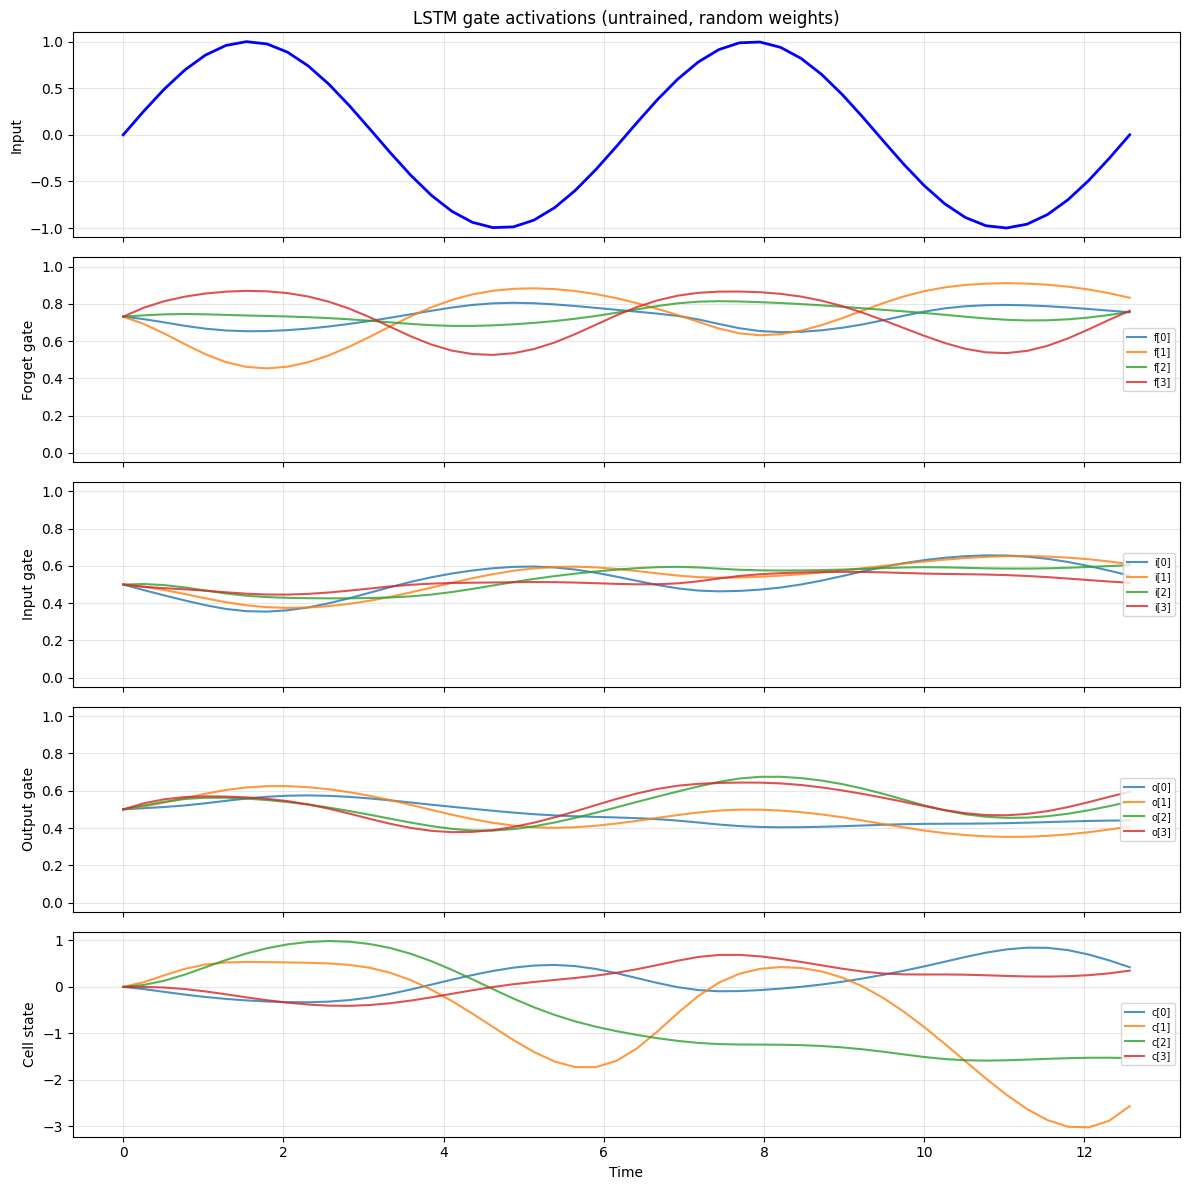

Forget gate: 1 に近い = 前の記憶を保持、0 に近い = 忘れる
Input gate:  1 に近い = 新情報を書き込む、0 に近い = 無視
Output gate: 1 に近い = セル状態を出力、0 に近い = 隠す
Cell state:  セル状態は tanh で押し潰されないので、値の範囲が広い（RNNの隠れ状態との違い）


In [2]:
# --- ゲートの動作を可視化 ---
fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)

# 入力
axes[0].plot(t_np, x_seq, 'b-', linewidth=2)
axes[0].set_ylabel('Input')
axes[0].set_title('LSTM gate activations (untrained, random weights)')
axes[0].grid(True, alpha=0.3)

# 忘却ゲート
for i in range(4):
    axes[1].plot(t_np, gates['forget'][:, i], label=f'f[{i}]', alpha=0.8)
axes[1].set_ylabel('Forget gate')
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(loc='right', fontsize=7)
axes[1].grid(True, alpha=0.3)

# 入力ゲート
for i in range(4):
    axes[2].plot(t_np, gates['input'][:, i], label=f'i[{i}]', alpha=0.8)
axes[2].set_ylabel('Input gate')
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend(loc='right', fontsize=7)
axes[2].grid(True, alpha=0.3)

# 出力ゲート
for i in range(4):
    axes[3].plot(t_np, gates['output'][:, i], label=f'o[{i}]', alpha=0.8)
axes[3].set_ylabel('Output gate')
axes[3].set_ylim(-0.05, 1.05)
axes[3].legend(loc='right', fontsize=7)
axes[3].grid(True, alpha=0.3)

# セル状態
for i in range(4):
    axes[4].plot(t_np, gates['cell'][:, i], label=f'c[{i}]', alpha=0.8)
axes[4].set_ylabel('Cell state')
axes[4].set_xlabel('Time')
axes[4].legend(loc='right', fontsize=7)
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Forget gate: 1 に近い = 前の記憶を保持、0 に近い = 忘れる")
print("Input gate:  1 に近い = 新情報を書き込む、0 に近い = 無視")
print("Output gate: 1 に近い = セル状態を出力、0 に近い = 隠す")
print("Cell state:  セル状態は tanh で押し潰されないので、値の範囲が広い（RNNの隠れ状態との違い）")

---
## Step 3: PyTorch で正弦波予測（RNN と同条件）

RNN ノートブックと **同じデータ・同じ条件** で LSTM を学習し、公平に比較します。

In [3]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# --- デバイス設定 ---
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Device: {device}")

Device: mps


In [4]:
# --- データセット作成（RNN ノートブックと同じ） ---

def create_sine_dataset(n_samples=1000, seq_len=20, freq_range=(0.5, 2.0)):
    X_list, y_list = [], []
    for _ in range(n_samples):
        freq = np.random.uniform(*freq_range)
        phase = np.random.uniform(0, 2 * np.pi)
        start = np.random.uniform(0, 10)
        t = np.linspace(start, start + 2 * np.pi, seq_len + 1)
        values = np.sin(freq * t + phase)
        X_list.append(values[:-1])
        y_list.append(values[1:])
    X = torch.FloatTensor(np.array(X_list)).unsqueeze(-1)
    y = torch.FloatTensor(np.array(y_list)).unsqueeze(-1)
    return X, y

# RNN と同じ条件
np.random.seed(42)
X_train, y_train = create_sine_dataset(n_samples=2000, seq_len=20)
X_test, y_test = create_sine_dataset(n_samples=200, seq_len=20)

BATCH_SIZE = 64
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: torch.Size([2000, 20, 1]), Test: torch.Size([200, 20, 1])


In [5]:
# --- モデル定義 ---

class SineRNN(nn.Module):
    """比較用の RNN モデル（rnn_basics.ipynb と同じ構造）"""
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x, h_0=None):
        if h_0 is None:
            h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        rnn_out, h_n = self.rnn(x, h_0)
        return self.fc(rnn_out)


class SineLSTM(nn.Module):
    """LSTM モデル"""
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x, hidden=None):
        if hidden is None:
            h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
            c_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
            hidden = (h_0, c_0)
        lstm_out, hidden = self.lstm(x, hidden)
        return self.fc(lstm_out)


model_rnn = SineRNN(hidden_size=32).to(device)
model_lstm = SineLSTM(hidden_size=32).to(device)

print(f"RNN  params: {sum(p.numel() for p in model_rnn.parameters()):,}")
print(f"LSTM params: {sum(p.numel() for p in model_lstm.parameters()):,}")
print(f"\nLSTM は RNN の約4倍のパラメータ（4つのゲート分の重みがあるため）")

RNN  params: 1,153
LSTM params: 4,513

LSTM は RNN の約4倍のパラメータ（4つのゲート分の重みがあるため）


### LSTM の `nn.LSTM` は何が違う？

```python
# RNN: 隠れ状態 h だけ
rnn_out, h_n = self.rnn(x, h_0)

# LSTM: 隠れ状態 h + セル状態 c のタプル
lstm_out, (h_n, c_n) = self.lstm(x, (h_0, c_0))
#                       ^^^^^^^^
#                       セル状態が追加されている
```

出力の `lstm_out` は RNN と同じ shape `(batch, seq_len, hidden_size)` なので、
後段の `nn.Linear` はそのまま使えます。

In [6]:
# --- 学習関数（RNN / LSTM 共通） ---

def train_model(model, train_loader, test_loader, epochs=50, lr=0.005):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses, test_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))
        
        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                test_loss += criterion(model(X_batch), y_batch).item()
        test_losses.append(test_loss / len(test_loader))
        
        if (epoch + 1) % 25 == 0:
            print(f"  Epoch [{epoch+1:3d}/{epochs}]  "
                  f"Train: {train_losses[-1]:.6f}  Test: {test_losses[-1]:.6f}")
    
    return train_losses, test_losses


# --- RNN 学習（50エポック） ---
print("=== RNN (50 epochs) ===")
rnn_train_loss, rnn_test_loss = train_model(model_rnn, train_loader, test_loader, epochs=50)

# --- LSTM 学習（150エポック: パラメータが4倍なのでより多く学習させる） ---
print("\n=== LSTM (150 epochs) ===")
lstm_train_loss, lstm_test_loss = train_model(model_lstm, train_loader, test_loader, epochs=150)

=== RNN (50 epochs) ===


  Epoch [ 25/50]  Train: 0.006424  Test: 0.006304


  Epoch [ 50/50]  Train: 0.004911  Test: 0.004557

=== LSTM (150 epochs) ===


  Epoch [ 25/150]  Train: 0.004793  Test: 0.004596


  Epoch [ 50/150]  Train: 0.004695  Test: 0.004403


  Epoch [ 75/150]  Train: 0.004619  Test: 0.004639


  Epoch [100/150]  Train: 0.004579  Test: 0.004360


  Epoch [125/150]  Train: 0.004633  Test: 0.004308


  Epoch [150/150]  Train: 0.004532  Test: 0.004357


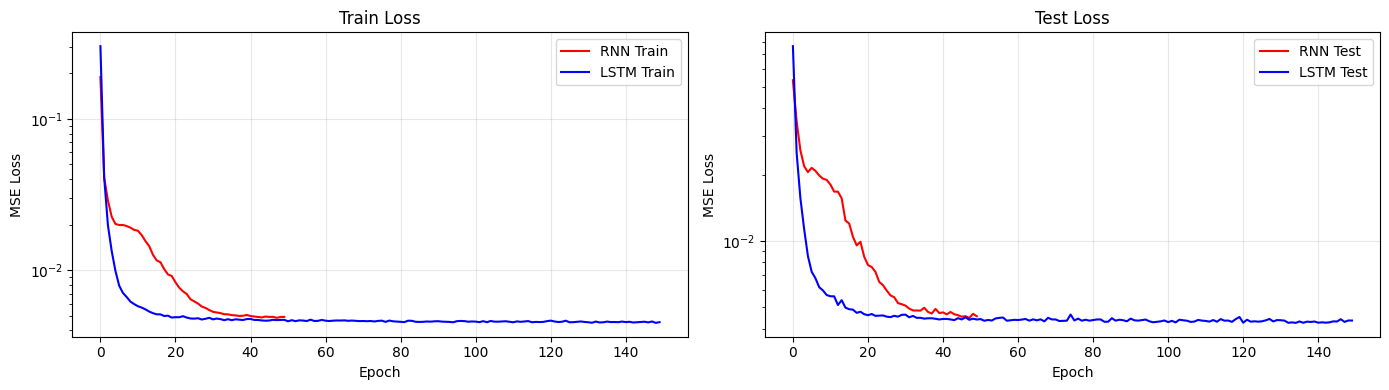

Final Test Loss - RNN: 0.004557, LSTM: 0.004357


In [7]:
# --- 学習曲線の比較 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(rnn_train_loss, 'r-', label='RNN Train')
axes[0].plot(lstm_train_loss, 'b-', label='LSTM Train')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Train Loss')
axes[0].legend()
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)

axes[1].plot(rnn_test_loss, 'r-', label='RNN Test')
axes[1].plot(lstm_test_loss, 'b-', label='LSTM Test')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Test Loss')
axes[1].legend()
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Test Loss - RNN: {rnn_test_loss[-1]:.6f}, LSTM: {lstm_test_loss[-1]:.6f}")

---
## Step 4: RNN vs LSTM の自己回帰生成を比較

同じ seed から波形を生成させて、どちらが長く正弦波を維持できるか確認します。

In [8]:
def autoregressive_generate_rnn(model, seed_values, n_generate=100):
    """RNN 用の自己回帰生成"""
    model.eval()
    generated = list(seed_values)
    input_seq = torch.FloatTensor(seed_values).reshape(1, -1, 1).to(device)
    
    with torch.no_grad():
        h = torch.zeros(1, 1, model.hidden_size).to(device)
        output, h = model.rnn(input_seq, h)
        last_pred = model.fc(output[:, -1:, :])
        generated.append(last_pred.item())
        
        for _ in range(n_generate - 1):
            output, h = model.rnn(last_pred, h)
            last_pred = model.fc(output)
            generated.append(last_pred.item())
    
    return np.array(generated)


def autoregressive_generate_lstm(model, seed_values, n_generate=100):
    """LSTM 用の自己回帰生成"""
    model.eval()
    generated = list(seed_values)
    input_seq = torch.FloatTensor(seed_values).reshape(1, -1, 1).to(device)
    
    with torch.no_grad():
        h = torch.zeros(1, 1, model.hidden_size).to(device)
        c = torch.zeros(1, 1, model.hidden_size).to(device)
        output, (h, c) = model.lstm(input_seq, (h, c))
        last_pred = model.fc(output[:, -1:, :])
        generated.append(last_pred.item())
        
        for _ in range(n_generate - 1):
            output, (h, c) = model.lstm(last_pred, (h, c))
            last_pred = model.fc(output)
            generated.append(last_pred.item())
    
    return np.array(generated)

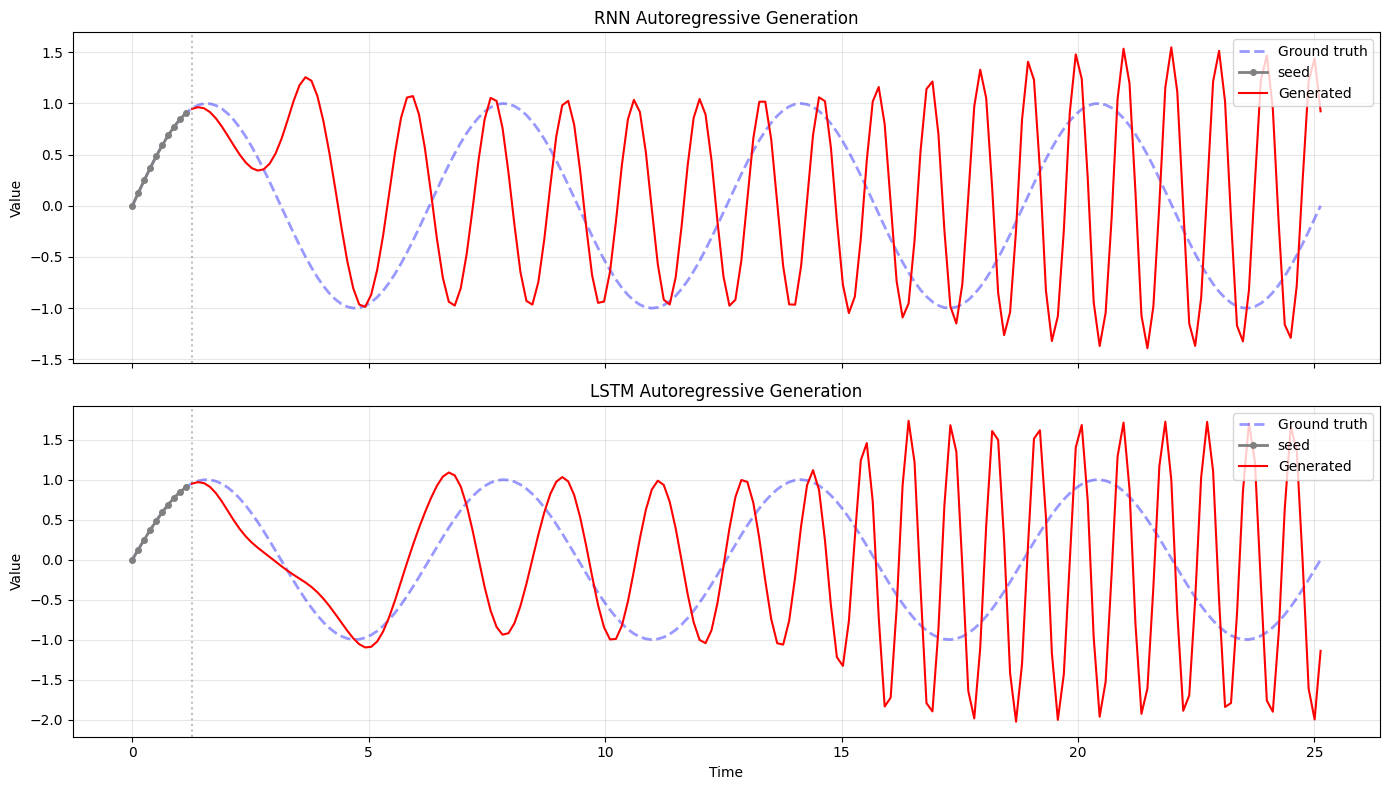

In [9]:
# --- 自己回帰生成の比較 ---
seed_len = 10
total_len = 200

t_true = np.linspace(0, 8 * np.pi, total_len)
true_wave = np.sin(t_true)
seed = true_wave[:seed_len]

gen_rnn = autoregressive_generate_rnn(model_rnn, seed, n_generate=total_len - seed_len)
gen_lstm = autoregressive_generate_lstm(model_lstm, seed, n_generate=total_len - seed_len)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, gen, title in [(axes[0], gen_rnn, 'RNN'), (axes[1], gen_lstm, 'LSTM')]:
    ax.plot(t_true, true_wave, 'b--', alpha=0.4, linewidth=2, label='Ground truth')
    ax.plot(t_true[:seed_len], gen[:seed_len], 'o-',
            color='gray', linewidth=2, markersize=4, label='seed')
    ax.plot(t_true[seed_len:len(gen)], gen[seed_len:], 'r-',
            linewidth=1.5, label='Generated')
    ax.axvline(x=t_true[seed_len], color='gray', linestyle=':', alpha=0.5)
    ax.set_ylabel('Value')
    ax.set_title(f'{title} Autoregressive Generation')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[1].set_xlabel('Time')
plt.tight_layout()
plt.show()

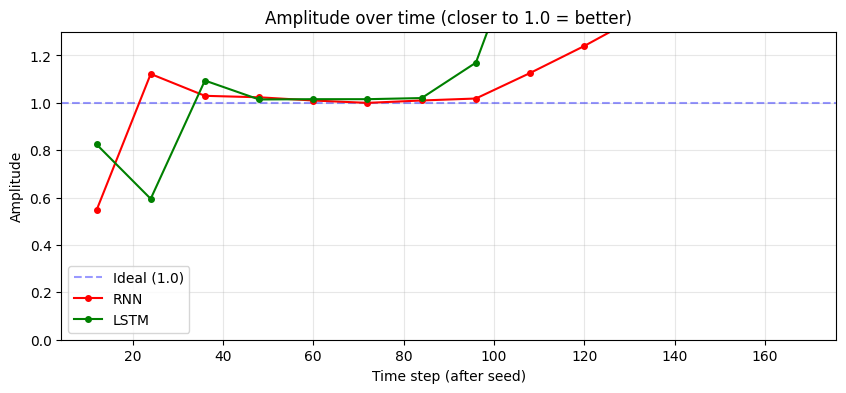

In [10]:
# --- 振幅の推移を定量比較 ---

def measure_amplitude(wave, window=25):
    """スライディングウィンドウで振幅（max - min）を計測"""
    amplitudes = []
    positions = []
    for i in range(0, len(wave) - window, window // 2):
        chunk = wave[i:i+window]
        amplitudes.append((np.max(chunk) - np.min(chunk)) / 2)
        positions.append(i + window // 2)
    return np.array(positions), np.array(amplitudes)


pos_rnn, amp_rnn = measure_amplitude(gen_rnn[seed_len:])
pos_lstm, amp_lstm = measure_amplitude(gen_lstm[seed_len:])

plt.figure(figsize=(10, 4))
plt.axhline(y=1.0, color='blue', linestyle='--', alpha=0.4, label='Ideal (1.0)')
plt.plot(pos_rnn, amp_rnn, 'r.-', label='RNN', markersize=8)
plt.plot(pos_lstm, amp_lstm, 'g.-', label='LSTM', markersize=8)
plt.xlabel('Time step (after seed)')
plt.ylabel('Amplitude')
plt.title('Amplitude over time (closer to 1.0 = better)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.3)
plt.show()

---
## Step 5: 学習済み LSTM のゲートを可視化

LSTM が sin 波の予測で **各ゲートをどう使っているか** を見てみます。
ゲートの活性化パターンから、LSTM が何を学んだかが読み取れます。

In [11]:
# --- 学習済み LSTM のゲート活性化を取得 ---

def extract_lstm_gates(model, input_seq):
    """
    学習済み LSTM に入力を通して、各ゲートの活性化を取得する。
    nn.LSTM は内部でゲートをまとめて計算するので、
    重みを取り出して手動で再計算する。
    """
    model.eval()
    
    # nn.LSTM の重みを取得
    # weight_ih_l0: (4*hidden_size, input_size) - [W_ii, W_if, W_ig, W_io]
    # weight_hh_l0: (4*hidden_size, hidden_size) - [W_hi, W_hf, W_hg, W_ho]
    W_ih = model.lstm.weight_ih_l0.detach().cpu().numpy()
    W_hh = model.lstm.weight_hh_l0.detach().cpu().numpy()
    b_ih = model.lstm.bias_ih_l0.detach().cpu().numpy()
    b_hh = model.lstm.bias_hh_l0.detach().cpu().numpy()
    
    hs = model.hidden_size
    x_np = input_seq.squeeze().cpu().numpy()
    
    h = np.zeros(hs)
    c = np.zeros(hs)
    
    gate_history = {'input': [], 'forget': [], 'cell_candidate': [],
                    'output': [], 'cell': [], 'hidden': []}
    
    for t in range(len(x_np)):
        x_t = x_np[t:t+1]  # (1,)
        
        # PyTorch LSTM の内部計算を再現
        # gates = W_ih @ x_t + b_ih + W_hh @ h + b_hh
        gates = W_ih @ x_t + b_ih + W_hh @ h + b_hh
        
        # PyTorch の順序: input, forget, cell_candidate(g), output
        i_gate = sigmoid(gates[0:hs])
        f_gate = sigmoid(gates[hs:2*hs])
        g_gate = np.tanh(gates[2*hs:3*hs])
        o_gate = sigmoid(gates[3*hs:4*hs])
        
        c = f_gate * c + i_gate * g_gate
        h = o_gate * np.tanh(c)
        
        gate_history['input'].append(i_gate)
        gate_history['forget'].append(f_gate)
        gate_history['cell_candidate'].append(g_gate)
        gate_history['output'].append(o_gate)
        gate_history['cell'].append(c.copy())
        gate_history['hidden'].append(h.copy())
    
    for key in gate_history:
        gate_history[key] = np.array(gate_history[key])
    
    return gate_history


# テストデータの1サンプルでゲートを抽出
test_input = X_test[0:1].to(device)
trained_gates = extract_lstm_gates(model_lstm, test_input)

print(f"Gate shapes: {trained_gates['forget'].shape}")
print("Gates extracted from trained LSTM.")

Gate shapes: (20, 32)
Gates extracted from trained LSTM.


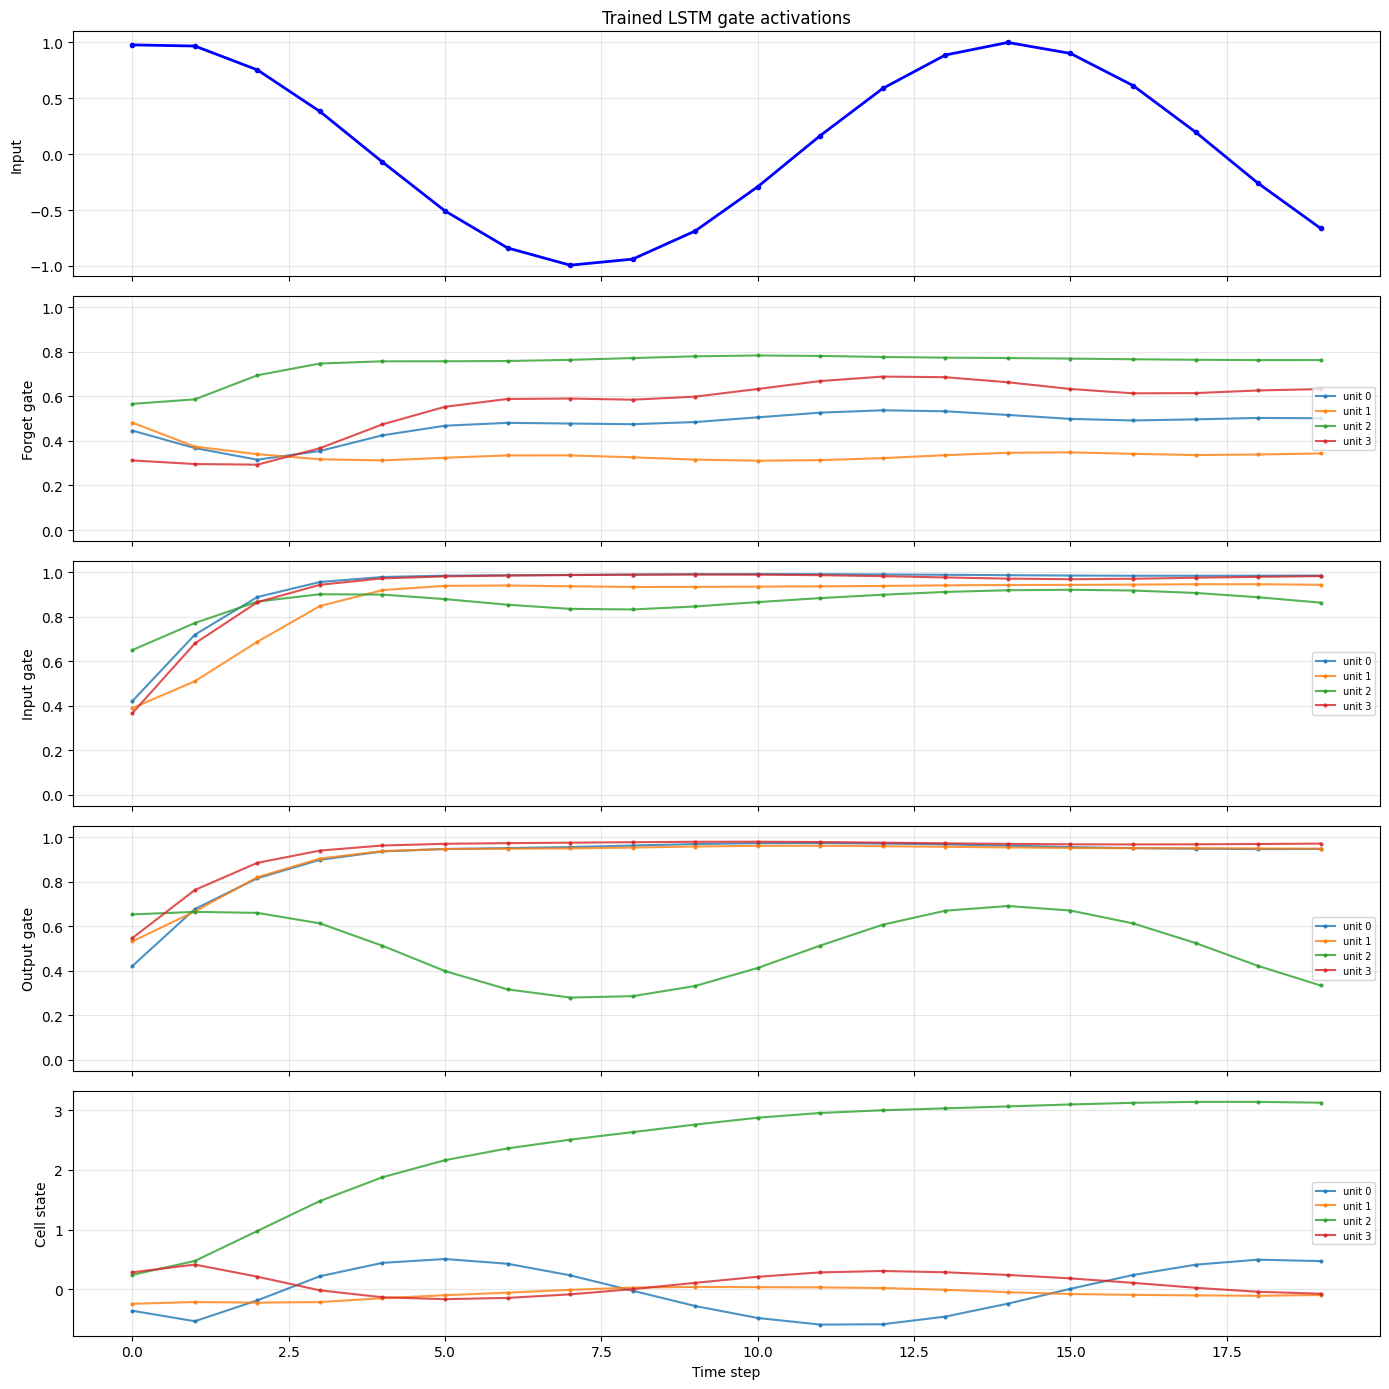

Forget gate が 1 に近い = 前の記憶を保持し続けている
Input gate が入力の波形に連動 = 入力の変化に応じて書き込み量を調整
Cell state が滑らかに推移 = tanh で潰されない長期記憶の証拠


In [12]:
# --- 学習済みゲートの可視化 ---

input_values = X_test[0].squeeze().numpy()
time_steps = range(len(input_values))
n_units = min(4, model_lstm.hidden_size)  # 最初の4ユニットを表示

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

# 入力
axes[0].plot(time_steps, input_values, 'b.-', linewidth=2, markersize=6)
axes[0].set_ylabel('Input')
axes[0].set_title('Trained LSTM gate activations')
axes[0].grid(True, alpha=0.3)

# 忘却ゲート
for i in range(n_units):
    axes[1].plot(time_steps, trained_gates['forget'][:, i],
                '.-', label=f'unit {i}', markersize=4, alpha=0.8)
axes[1].set_ylabel('Forget gate')
axes[1].set_ylim(-0.05, 1.05)
axes[1].legend(loc='right', fontsize=7)
axes[1].grid(True, alpha=0.3)

# 入力ゲート
for i in range(n_units):
    axes[2].plot(time_steps, trained_gates['input'][:, i],
                '.-', label=f'unit {i}', markersize=4, alpha=0.8)
axes[2].set_ylabel('Input gate')
axes[2].set_ylim(-0.05, 1.05)
axes[2].legend(loc='right', fontsize=7)
axes[2].grid(True, alpha=0.3)

# 出力ゲート
for i in range(n_units):
    axes[3].plot(time_steps, trained_gates['output'][:, i],
                '.-', label=f'unit {i}', markersize=4, alpha=0.8)
axes[3].set_ylabel('Output gate')
axes[3].set_ylim(-0.05, 1.05)
axes[3].legend(loc='right', fontsize=7)
axes[3].grid(True, alpha=0.3)

# セル状態
for i in range(n_units):
    axes[4].plot(time_steps, trained_gates['cell'][:, i],
                '.-', label=f'unit {i}', markersize=4, alpha=0.8)
axes[4].set_ylabel('Cell state')
axes[4].set_xlabel('Time step')
axes[4].legend(loc='right', fontsize=7)
axes[4].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Forget gate が 1 に近い = 前の記憶を保持し続けている")
print("Input gate が入力の波形に連動 = 入力の変化に応じて書き込み量を調整")
print("Cell state が滑らかに推移 = tanh で潰されない長期記憶の証拠")

---
## まとめ

### RNN vs LSTM

| 項目 | RNN | LSTM |
|------|-----|------|
| 記憶の仕組み | 隠れ状態 $h_t$ のみ | セル状態 $c_t$（長期）+ 隠れ状態 $h_t$（短期） |
| 情報の制御 | なし（毎回 tanh で混ぜるだけ） | 3つのゲートで精密に制御 |
| 勾配の流れ | 毎回行列積 + tanh → 勾配消失 | セル状態はスカラー積のみ → 勾配が保持される |
| パラメータ数 | 少ない | RNN の約4倍（4つのゲート分） |
| 自己回帰生成 | 振幅・周波数が早く崩れる | より長く波形を維持できる |

### LSTM の核心

```
c_t = f_t * c_{t-1} + i_t * tanh(W_c [h_{t-1}, x_t])
      ^^^^^^^^^^^^^^   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
      古い記憶を残す     新しい情報を追加する
```

この「**足し算で記憶を更新する**」構造が、勾配消失を防ぐ鍵です。

### 次のステップ

1. **音声データ（MFCC特徴量）** で LSTM を使った分類に挑戦
2. **Attention / Transformer** で「どこに注目するか」を学習するメカニズムへ